# STARTER

In [ ]:
import sys
import pathlib

# Get project root (parent of generation/)
project_root = pathlib.Path().resolve().parent
sys.path.insert(0, str(project_root))

# MANIFESTO

In [ ]:
from scripts.utils.logger import logger

In [ ]:
logger_params = {
    "main_folder": "/home/think/Desktop/strats",
    "experiment_name": "LSTM_multivariate_1_strats",
    "date": "2025-10-11",
    "iteration": 1,
    "description": (
        "Se entrenara una LSTM con lorenz63 canonico caotico"
        "en modo multivariable 1 (all for one) para las 5 strategies,"
        "el proposito es que podamos dejar una plantilla"
    )
}

In [ ]:
exp_folder, manifesto_path = logger(logger_params)
print(f"Experiment folder created at: {exp_folder}")
print(f"Manifesto written to: {manifesto_path}")

# DATA

In [ ]:
from scripts.data_generation.binder import Binder
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scripts.data_generation.tsdg import DynamicalSystem
from sklearn.preprocessing import MinMaxScaler

# --- Data Generation ---
model_name = 'lorenz63'
sigma = 10 
beta = 8/3
rho = 28
params = (sigma, beta, rho)
binder = Binder("scripts.systems.lorenz63", "lorenz63", params)
binder.import_module()      
model_fixed = binder.fixer()
t_span = (0, 100)
t_eval = np.linspace(t_span[0], t_span[1], 1000)
y0 = np.array([0.1, 0.1, 0.1])
ds1 = DynamicalSystem(model_fixed, y0, t_eval, notebook = True)
_ = ds1.solve()

# --- Convert to dataframe ---
sample = ds1.to_dataframe()

# Train and Test Split
Full = sample.values
n_samples = len(Full)

train_size = int(0.60 * n_samples)   # 70% for training
val_size = int(0.20 * n_samples)     # 10% for validation
test_size = n_samples - train_size - val_size  # remaining 20% for testing

train_data = Full[:train_size]
val_data = Full[train_size:train_size+val_size]
test_data = Full[train_size+val_size:]

# --- Scaling ---
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data.reshape(-1, 1)).flatten()
val_scaled = scaler.transform(val_data.reshape(-1, 1)).flatten()
test_scaled = scaler.transform(test_data.reshape(-1, 1)).flatten()

# # We fit on train but immediately transform test here for simplicity
# test_scaled  = scaler.transform(test_data.reshape(-1, 1)).flatten()
# # If you want the prediction back in original units:
# # yhat = scaler.inverse_transform(yhat_scaled)

In [ ]:
for i in range(len(sample.columns)):
    # Define x-axis ranges based on the lengths
    train_end = len(train_data[:,i])
    val_end = len(train_data[:,i]) + len(val_data[:,i])
    x_train = np.arange(train_end)
    x_val =np.arange(train_end, train_end + len(val_data[:,i]))
    x_test = np.arange(val_end, val_end + len(test_data[:,i]))
    # Plot
    plt.figure(figsize=(10, 2))
    plt.plot(x_train, train_data[:,i], label='Train', color='blue')
    plt.plot(x_val, val_data[:,i], label='Val', color='green')
    plt.plot(x_test, test_data[:,i], label='Test', color='orange')

    # Optional vertical line to indicate the split
    plt.axvline(x=train_end, color='red', linestyle='--') #label='Train/Test Split'
    plt.axvline(x=val_end, color='black', linestyle='--') #label='Train/Test Split'
    plt.legend()
    plt.title("Train/Val/Test Split Visualization")
    plt.xlabel("Time Step")
    plt.ylabel("Value")
    plt.tight_layout()
    plt.show()

# RECURSIVE-MULTIVARIATE-ALL_FOR_ALL

In [15]:
from numpy import array
from numpy import hstack
# define input sequence
in_seq1 = array([10,20,30, 40, 50, 60,70,80,90])
in_seq2 = array([15,25,35,45,55,65,75,85,95])
out_seq = array([in_seq1[i] + in_seq2[i] for i in range(len(in_seq1))])
# convert to [rows, columns] structure
in_seq1 = in_seq1.reshape((len(in_seq1), 1))
in_seq2 = in_seq2.reshape((len(in_seq2), 1))
out_seq = out_seq.reshape((len(out_seq), 1))
# horizontally stack columns
dataset = hstack((in_seq1, in_seq2, out_seq))

In [ ]:
# split a multivariate sequence into samples
def split_sequences(sequences, n_steps_in, n_steps_out):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the dataset
        if out_end_ix > len(sequences):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :], sequences[end_ix:out_end_ix, :]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [17]:
# choose a number of time steps
n_steps_in, n_steps_out = 1, 1
# convert into input/output
X, y = split_sequences(dataset, n_steps_in, n_steps_out)

In [32]:
X.shape

(8, 1, 3)

In [18]:
for i in range(len(X)):
    print(X[i], y[i])

[[10 15 25]] [[20 25 45]]
[[20 25 45]] [[30 35 65]]
[[30 35 65]] [[40 45 85]]
[[40 45 85]] [[ 50  55 105]]
[[ 50  55 105]] [[ 60  65 125]]
[[ 60  65 125]] [[ 70  75 145]]
[[ 70  75 145]] [[ 80  85 165]]
[[ 80  85 165]] [[ 90  95 185]]


In [24]:
X.shape[2]

3

In [19]:
# the dataset knows the number of featrues, e.g. 2
n_features = X.shape[2]

# multivariate multi-step  encoder-decoder lstm example

from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense
from keras.layers import Reshape

def vanilla_lstm(n_steps_in, n_steps_out, n_features, units=100):
    model = Sequential()
    model.add(LSTM(units, activation='relu', input_shape=(n_steps_in, n_features)))
    model.add(Dense(n_steps_out * n_features))  # predict all future timesteps × features
    model.add(Reshape((n_steps_out, n_features)))  # reshape to proper output structure
    model.compile(optimizer='adam', loss='mse')
    return model

In [20]:
model_recursive = vanilla_lstm(n_steps_in, n_steps_out, n_features)
model_recursive.fit(X, y, epochs=800, verbose=0)

/home/think/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
# demonstrate prediction
x_input = array([[90,95, 185]])
x_input = x_input.reshape((1, n_steps_in, n_features))
yhat = model_recursive.predict(x_input, verbose=0)
print(yhat)

[[[100.74701  106.474556 207.145   ]]]


In [35]:
from sklearn import metrics
from scipy.stats import skew
import numpy as np


def recursive_predictions(starter_sample, horizon, model, scaler = None):
    # Initialize input, start with the last value of the training data
    n_steps_in = starter_sample.shape[0]
    n_features = starter_sample.shape[1]
    uno = starter_sample.reshape((1, n_steps_in, n_features))
    # List to store predictions
    predictions = []
    # Loop to predict one step at a time
    for i in range(horizon):
        yhat_scaled = model.predict(uno, verbose=0)
        # Save prediction in original units
        if scaler is not None:
            yhat_inv = scaler.inverse_transform(yhat_scaled)
            predictions.append(yhat_inv)
        else:
            predictions.append(yhat_scaled)

        # Feed back the scaled value to the model
        uno = yhat_scaled.reshape((1, n_steps_in, n_features)) 
     
    # Convert predictions to numpy array
    predictions = np.array(predictions)
    return predictions

In [36]:
starter_sample = array([[90,95, 185]])
horizon = 20
recurs_preds_1 = recursive_predictions(starter_sample, horizon, model_recursive, scaler = None)

In [102]:
test_seq_1 = array([i for i in range(100,300, 10)])
test_seq_2 = array([i for i in range(105,305, 10)])
test_seq_3 = array([test_seq_1[i] + test_seq_2[i] for i in range(len(test_seq_1))])
# convert to [rows, columns] structure
test_seq_1 = test_seq_1.reshape((len(test_seq_1), 1))
test_seq_2 = test_seq_2.reshape((len(test_seq_2), 1))
test_seq_3 = test_seq_3.reshape((len(test_seq_3), 1))
# horizontally stack columns
test_dataset = hstack((test_seq_1, test_seq_2, test_seq_3))

In [101]:
# i = 2
# for item in recurs_preds_1:
#     print(item[0][0][i])

In [103]:
import numpy as np

# recurs_preds_1 has shape (n_samples,1,1,n_features)
series = np.array(recurs_preds_1)          # make sure it's a NumPy array
series = series.reshape(len(series), -1)   # shape becomes (n_samples, n_features)


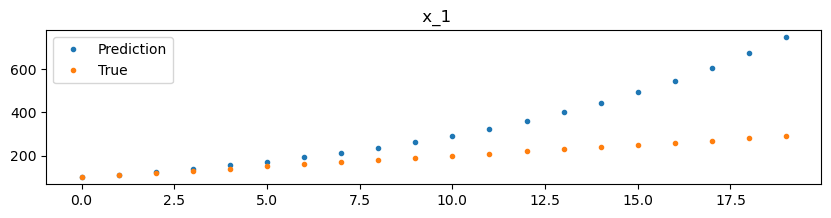

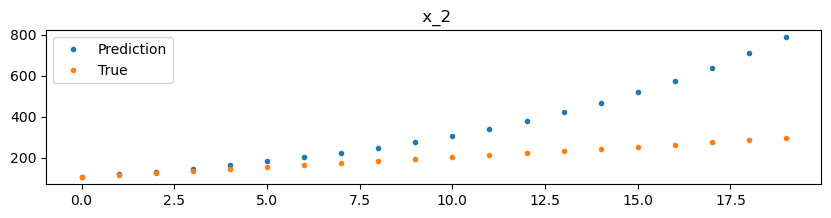

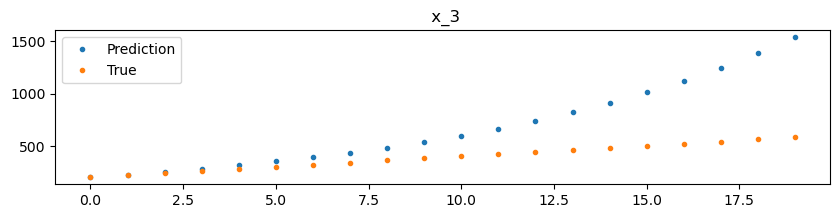

In [105]:
import matplotlib.pyplot as plt

n_features = series.shape[1]

for i in range(n_features):
    plt.figure(figsize=(10, 2))
    plt.plot(series[:, i], linestyle=' ', marker='.', label='Prediction')
    plt.plot(test_dataset[:, i], linestyle=' ', marker='.', label='True')
    plt.title(f' x_{i+1}')
    plt.legend()
    plt.show()


# DIRECT-MULTIVARIATE-ALL_FOR_ALL

In [1]:
from numpy import array
from numpy import hstack
# define input sequence
in_seq1 = array([10,20,30, 40, 50, 60,70,80,90])
in_seq2 = array([15,25,35,45,55,65,75,85,95])
out_seq = array([in_seq1[i] + in_seq2[i] for i in range(len(in_seq1))])
# convert to [rows, columns] structure
in_seq1 = in_seq1.reshape((len(in_seq1), 1))
in_seq2 = in_seq2.reshape((len(in_seq2), 1))
out_seq = out_seq.reshape((len(out_seq), 1))
# horizontally stack columns
dataset = hstack((in_seq1, in_seq2, out_seq))

In [47]:
# split a multivariate sequence into samples
def split_sequences_v1(sequences, n_steps_in, n_steps_out, skip):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the dataset
        if out_end_ix > len(sequences) - skip:
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :], sequences[skip + end_ix:out_end_ix + skip , :]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [22]:
n_steps_in = 1
n_steps_out = 1
horizon = 5
datasets = {}
for i in range(horizon):
    skip = i
    X, y = split_sequences_v1(dataset, n_steps_in, n_steps_out, skip)
    X = X.reshape((X.shape[0], X.shape[1], X.shape[2]))
    datasets[i] = (X, y)  # store as tuple

In [7]:
for i in datasets:
    print(i, end=' ')

0 1 2 3 4 

In [10]:
X, y = datasets[4]
print(X.shape)
print(y.shape)
for xi, yi in zip(X, y):
    print(xi,yi)

(4, 1, 3)
(4, 1, 3)
[[10 15 25]] [[ 60  65 125]]
[[20 25 45]] [[ 70  75 145]]
[[30 35 65]] [[ 80  85 165]]
[[40 45 85]] [[ 90  95 185]]


In [12]:
# the dataset knows the number of featrues, e.g. 2
n_features = X.shape[2]

# multivariate multi-step  encoder-decoder lstm example

from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense
from keras.layers import Reshape

def vanilla_lstm(n_steps_in, n_steps_out, n_features, units=100):
    model = Sequential()
    model.add(LSTM(units, activation='relu', input_shape=(n_steps_in, n_features)))
    model.add(Dense(n_steps_out * n_features))  # predict all future timesteps × features
    model.add(Reshape((n_steps_out, n_features)))  # reshape to proper output structure
    model.compile(optimizer='adam', loss='mse')
    return model

In [14]:
models = {}
for i, (X, y) in datasets.items():  # i is literally 0, 1, 2...
    model = vanilla_lstm(n_steps_in,n_steps_out, n_features)
    model.fit(X, y, epochs=500, verbose=0)
    models[i] = model  # store the trained model for that step

2025-10-14 00:42:31.153003: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/think/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
starter_sample = array([[90,95,185]]).reshape((1, n_steps_in, n_features)) 
predictions_direct = []

for i in models:  # skip = number of horizons / models
    model = models[i]
    yhat = model.predict(starter_sample, verbose=0)
    predictions_direct.append(yhat)  # flatten the output

In [16]:
predictions_direct

[array([[[100.77601, 106.69959, 208.51509]]], dtype=float32),
 array([[[111.90882, 120.78817, 235.0041 ]]], dtype=float32),
 array([[[128.65266, 135.18497, 264.26706]]], dtype=float32),
 array([[[153.3934 , 158.23065, 328.9035 ]]], dtype=float32),
 array([[[185.07848, 194.91927, 409.62494]]], dtype=float32)]

In [17]:
import numpy as np

# recurs_preds_1 has shape (n_samples,1,1,n_features)
predictions_direct = np.array(predictions_direct)          # make sure it's a NumPy array
predictions_direct = predictions_direct.reshape(len(predictions_direct), -1)   # shape becomes (n_samples, n_features)

In [18]:
predictions_direct

array([[100.77601, 106.69959, 208.51509],
       [111.90882, 120.78817, 235.0041 ],
       [128.65266, 135.18497, 264.26706],
       [153.3934 , 158.23065, 328.9035 ],
       [185.07848, 194.91927, 409.62494]], dtype=float32)

In [19]:
test_seq_1 = array([i for i in range(100,300, 10)])
test_seq_2 = array([i for i in range(105,305, 10)])
test_seq_3 = array([test_seq_1[i] + test_seq_2[i] for i in range(len(test_seq_1))])
# convert to [rows, columns] structure
test_seq_1 = test_seq_1.reshape((len(test_seq_1), 1))
test_seq_2 = test_seq_2.reshape((len(test_seq_2), 1))
test_seq_3 = test_seq_3.reshape((len(test_seq_3), 1))
# horizontally stack columns
test_dataset = hstack((test_seq_1, test_seq_2, test_seq_3))

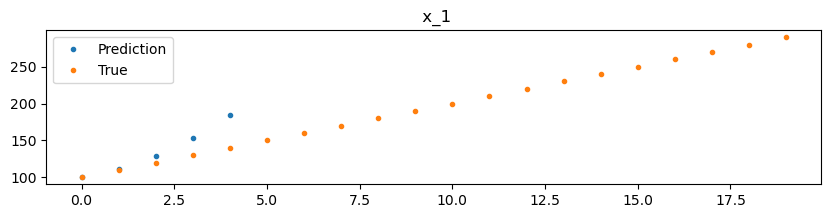

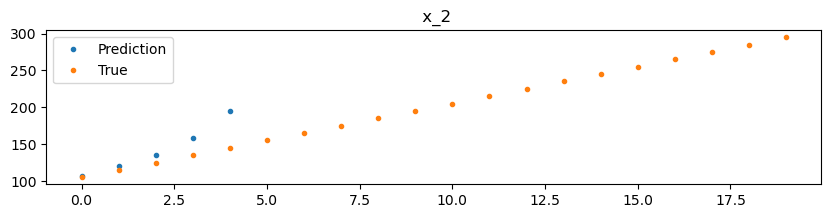

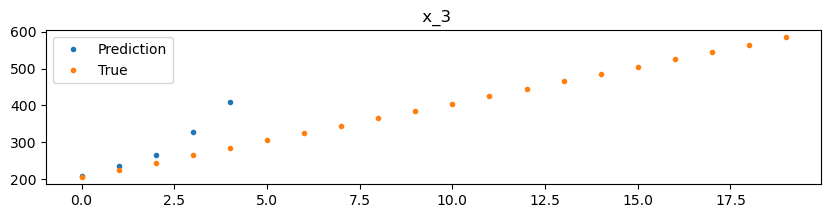

In [20]:
import matplotlib.pyplot as plt

n_features = predictions_direct.shape[1]

for i in range(n_features):
    plt.figure(figsize=(10, 2))
    plt.plot(predictions_direct[:, i], linestyle=' ', marker='.', label='Prediction')
    plt.plot(test_dataset[:, i], linestyle=' ', marker='.', label='True')
    plt.title(f' x_{i+1}')
    plt.legend()
    plt.show()

# DIREC-MULTIVARIATE-ALL_FOR_ALL
Dividir el horizonte $H$ en bloques $B$ de modo que $H/B = N$. Se entrena un modelo para predecir $B$ pasos, y la predicción del bloque se reutiliza como entrada del siguiente bloque hasta alcanzar $H$. 

In [23]:
from numpy import array
from numpy import hstack
# define input sequence
in_seq1 = array([10,20,30, 40, 50, 60,70,80,90])
in_seq2 = array([15,25,35,45,55,65,75,85,95])
out_seq = array([in_seq1[i] + in_seq2[i] for i in range(len(in_seq1))])
# convert to [rows, columns] structure
in_seq1 = in_seq1.reshape((len(in_seq1), 1))
in_seq2 = in_seq2.reshape((len(in_seq2), 1))
out_seq = out_seq.reshape((len(out_seq), 1))
# horizontally stack columns
dataset = hstack((in_seq1, in_seq2, out_seq))

In [25]:
# split a multivariate sequence into samples
def split_sequences(sequences, n_steps_in, n_steps_out):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the dataset
        if out_end_ix > len(sequences):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :], sequences[end_ix:out_end_ix, :]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [27]:
# choose a number of time steps
n_steps_in, n_steps_out = 2, 2
# convert into input/output
X, y = split_sequences(dataset, n_steps_in, n_steps_out)

In [28]:
for i in range(len(X)):
    print(X[i], y[i])

[[10 15 25]
 [20 25 45]] [[30 35 65]
 [40 45 85]]
[[20 25 45]
 [30 35 65]] [[ 40  45  85]
 [ 50  55 105]]
[[30 35 65]
 [40 45 85]] [[ 50  55 105]
 [ 60  65 125]]
[[ 40  45  85]
 [ 50  55 105]] [[ 60  65 125]
 [ 70  75 145]]
[[ 50  55 105]
 [ 60  65 125]] [[ 70  75 145]
 [ 80  85 165]]
[[ 60  65 125]
 [ 70  75 145]] [[ 80  85 165]
 [ 90  95 185]]


In [29]:
# the dataset knows the number of featrues, e.g. 2
n_features = X.shape[2]

# multivariate multi-step  encoder-decoder lstm example

from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense
from keras.layers import Reshape

def vanilla_lstm(n_steps_in, n_steps_out, n_features, units=100):
    model = Sequential()
    model.add(LSTM(units, activation='relu', input_shape=(n_steps_in, n_features)))
    model.add(Dense(n_steps_out * n_features))  # predict all future timesteps × features
    model.add(Reshape((n_steps_out, n_features)))  # reshape to proper output structure
    model.compile(optimizer='adam', loss='mse')
    return model

In [32]:
model_recursive = vanilla_lstm(n_steps_in, n_steps_out, n_features)
model_recursive.fit(X, y, epochs=800, verbose=0)

/home/think/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [33]:
# demonstrate prediction
x_input = array([[80,85,165],[90,95,185]])
x_input = x_input.reshape((1, n_steps_in, n_features))
yhat = model_recursive.predict(x_input, verbose=0)
print(yhat)

[[[101.14846 106.49365 207.9556 ]
  [112.41253 117.51403 229.32231]]]


In [34]:
x_input = array([[80,85,165],[90,95,185]])
print(x_input.shape)

(2, 3)


In [35]:
from sklearn import metrics
from scipy.stats import skew
import numpy as np


def recursive_predictions(starter_sample, horizon, model, scaler = None):
    # Initialize input, start with the last value of the training data
    n_steps_in = starter_sample.shape[0]
    n_features = starter_sample.shape[1]
    uno = starter_sample.reshape((1, n_steps_in, n_features))
    # List to store predictions
    predictions = []
    # Loop to predict one step at a time
    for i in range(horizon):
        yhat_scaled = model.predict(uno, verbose=0)
        # Save prediction in original units
        if scaler is not None:
            yhat_inv = scaler.inverse_transform(yhat_scaled)
            predictions.append(yhat_inv)
        else:
            predictions.append(yhat_scaled)

        # Feed back the scaled value to the model
        uno = yhat_scaled.reshape((1, n_steps_in, n_features)) 
     
    # Convert predictions to numpy array
    predictions = np.array(predictions)
    return predictions

In [36]:
starter_sample = array([[80,85,165],[90,95,185]])
horizon = 20
recurs_preds_1 = recursive_predictions(starter_sample, horizon, model_recursive, scaler = None)

In [37]:
test_seq_1 = array([i for i in range(100,300, 10)])
test_seq_2 = array([i for i in range(105,305, 10)])
test_seq_3 = array([test_seq_1[i] + test_seq_2[i] for i in range(len(test_seq_1))])
# convert to [rows, columns] structure
test_seq_1 = test_seq_1.reshape((len(test_seq_1), 1))
test_seq_2 = test_seq_2.reshape((len(test_seq_2), 1))
test_seq_3 = test_seq_3.reshape((len(test_seq_3), 1))
# horizontally stack columns
test_dataset = hstack((test_seq_1, test_seq_2, test_seq_3))

In [38]:
import numpy as np

# recurs_preds_1 has shape (n_samples,1,1,n_features)
series = np.array(recurs_preds_1)          # make sure it's a NumPy array
series = series.reshape(len(series), -1)   # shape becomes (n_samples, n_features)


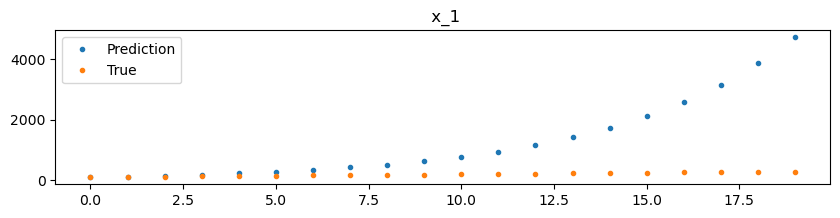

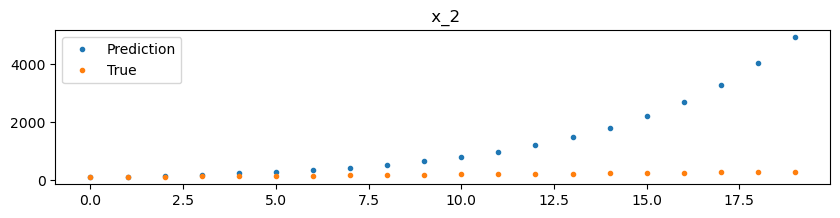

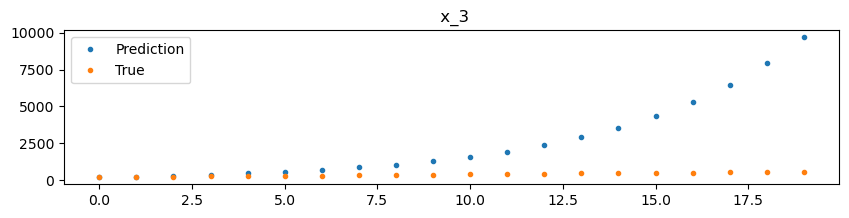

In [41]:
import matplotlib.pyplot as plt

n_features = starter_sample.shape[1]

for i in range(n_features):
    plt.figure(figsize=(10, 2))
    plt.plot(series[:, i], linestyle=' ', marker='.', label='Prediction')
    plt.plot(test_dataset[:, i], linestyle=' ', marker='.', label='True')
    plt.title(f' x_{i+1}')
    plt.legend()
    plt.show()

# MIMO-MULTIVARIATE-ALL_FOR_ALL

In [ ]:
from numpy import array
from numpy import hstack
# define input sequence
in_seq1 = array([10,20,30, 40, 50, 60,70,80,90])
in_seq2 = array([15,25,35,45,55,65,75,85,95])
out_seq = array([in_seq1[i] + in_seq2[i] for i in range(len(in_seq1))])
# convert to [rows, columns] structure
in_seq1 = in_seq1.reshape((len(in_seq1), 1))
in_seq2 = in_seq2.reshape((len(in_seq2), 1))
out_seq = out_seq.reshape((len(out_seq), 1))
# horizontally stack columns
dataset = hstack((in_seq1, in_seq2, out_seq))

In [ ]:
# split a multivariate sequence into samples
def split_sequences(sequences, n_steps_in, n_steps_out):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the dataset
        if out_end_ix > len(sequences):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :], sequences[end_ix:out_end_ix, :]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [44]:
# choose a number of time steps
n_steps_in, n_steps_out = 3, 5
# convert into input/output
X, y = split_sequences(dataset, n_steps_in, n_steps_out)

In [45]:
for i in range(len(X)):
    print(X[i], y[i])

[[10 15 25]
 [20 25 45]
 [30 35 65]] [[ 40  45  85]
 [ 50  55 105]
 [ 60  65 125]
 [ 70  75 145]
 [ 80  85 165]]
[[20 25 45]
 [30 35 65]
 [40 45 85]] [[ 50  55 105]
 [ 60  65 125]
 [ 70  75 145]
 [ 80  85 165]
 [ 90  95 185]]


In [46]:
# the dataset knows the number of featrues, e.g. 2
n_features = X.shape[2]

# multivariate multi-step  encoder-decoder lstm example

from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense
from keras.layers import Reshape

def vanilla_lstm(n_steps_in, n_steps_out, n_features, units=100):
    model = Sequential()
    model.add(LSTM(units, activation='relu', input_shape=(n_steps_in, n_features)))
    model.add(Dense(n_steps_out * n_features))  # predict all future timesteps × features
    model.add(Reshape((n_steps_out, n_features)))  # reshape to proper output structure
    model.compile(optimizer='adam', loss='mse')
    return model

In [ ]:
model_recursive = vanilla_lstm(n_steps_in, n_steps_out, n_features)
model_recursive.fit(X, y, epochs=800, verbose=0)

In [ ]:
# demonstrate prediction
x_input = array([[90,95, 185]])
x_input = x_input.reshape((1, n_steps_in, n_features))
yhat = model_recursive.predict(x_input, verbose=0)
print(yhat)

In [ ]:
import numpy as np

# recurs_preds_1 has shape (n_samples,1,1,n_features)
series = np.array(recurs_preds_1)          # make sure it's a NumPy array
series = series.reshape(len(series), -1)   # shape becomes (n_samples, n_features)

In [ ]:
test_seq_1 = array([i for i in range(100,300, 10)])
test_seq_2 = array([i for i in range(105,305, 10)])
test_seq_3 = array([test_seq_1[i] + test_seq_2[i] for i in range(len(test_seq_1))])
# convert to [rows, columns] structure
test_seq_1 = test_seq_1.reshape((len(test_seq_1), 1))
test_seq_2 = test_seq_2.reshape((len(test_seq_2), 1))
test_seq_3 = test_seq_3.reshape((len(test_seq_3), 1))
# horizontally stack columns
test_dataset = hstack((test_seq_1, test_seq_2, test_seq_3))

In [ ]:
import matplotlib.pyplot as plt

n_features = series.shape[1]

for i in range(n_features):
    plt.figure(figsize=(10, 2))
    plt.plot(series[:, i], linestyle=' ', marker='.', label='Prediction')
    plt.plot(test_dataset[:, i], linestyle=' ', marker='.', label='True')
    plt.title(f' x_{i+1}')
    plt.legend()
    plt.show()

# DIRMO-MULTIVARIATE-ALL_FOR_ALL
Dividir el horizonte $H$ en bloques $B$ de modo que $H/B = N$, y entrenar $N$ modelos, cada uno encargado de predecir $B$ pasos consecutivos. 

In [124]:
# DIRECT-MULTIVARIATE-ALL_FOR_ALL
from numpy import array
from numpy import hstack
# define input sequence
in_seq1 = array([10,20,30, 40, 50, 60,70,80,90])
in_seq2 = array([15,25,35,45,55,65,75,85,95])
out_seq = array([in_seq1[i] + in_seq2[i] for i in range(len(in_seq1))])
# convert to [rows, columns] structure
in_seq1 = in_seq1.reshape((len(in_seq1), 1))
in_seq2 = in_seq2.reshape((len(in_seq2), 1))
out_seq = out_seq.reshape((len(out_seq), 1))
# horizontally stack columns
dataset = hstack((in_seq1, in_seq2, out_seq))

In [125]:
# split a multivariate sequence into samples
def split_sequences_v1(sequences, n_steps_in, n_steps_out, skip):
    X, y = list(), list()
    for i in range(len(sequences)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the dataset
        if out_end_ix > len(sequences)-skip:
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :], sequences[skip + end_ix:out_end_ix + skip , :]
        X.append(seq_x)
        y.append(seq_y)
    return array(X), array(y)

In [130]:
n_steps_in = 1
n_steps_out = 2
horizon = 8
skip = n_steps_out
datasets = {}
for i in range(0, horizon, skip):
    X, y = split_sequences_v1(dataset, n_steps_in, n_steps_out, i)
    if len(X) == 0:
        raise ValueError(f"Insufficient data points for skip={i}.")
    #X = X.reshape((X.shape[0], X.shape[1], X.shape[2]))
    datasets[i] = (X, y)  # store as tuple

In [131]:
for i in datasets:
    print(i, end=' ')

0 2 4 6 

In [149]:
X, y = datasets[0]
print(X.shape)
print(y.shape)
for xi, yi in zip(X, y):
    print(xi,yi)

(7, 1, 3)
(7, 2, 3)
[[10 15 25]] [[20 25 45]
 [30 35 65]]
[[20 25 45]] [[30 35 65]
 [40 45 85]]
[[30 35 65]] [[ 40  45  85]
 [ 50  55 105]]
[[40 45 85]] [[ 50  55 105]
 [ 60  65 125]]
[[ 50  55 105]] [[ 60  65 125]
 [ 70  75 145]]
[[ 60  65 125]] [[ 70  75 145]
 [ 80  85 165]]
[[ 70  75 145]] [[ 80  85 165]
 [ 90  95 185]]


In [150]:
X, y = datasets[2]
print(X.shape)
print(y.shape)
for xi, yi in zip(X, y):
    print(xi,yi)

(5, 1, 3)
(5, 2, 3)
[[10 15 25]] [[ 40  45  85]
 [ 50  55 105]]
[[20 25 45]] [[ 50  55 105]
 [ 60  65 125]]
[[30 35 65]] [[ 60  65 125]
 [ 70  75 145]]
[[40 45 85]] [[ 70  75 145]
 [ 80  85 165]]
[[ 50  55 105]] [[ 80  85 165]
 [ 90  95 185]]


In [151]:
X, y = datasets[4]
print(X.shape)
print(y.shape)
for xi, yi in zip(X, y):
    print(xi,yi)

(3, 1, 3)
(3, 2, 3)
[[10 15 25]] [[ 60  65 125]
 [ 70  75 145]]
[[20 25 45]] [[ 70  75 145]
 [ 80  85 165]]
[[30 35 65]] [[ 80  85 165]
 [ 90  95 185]]


In [132]:
X, y = datasets[6]
print(X.shape)
print(y.shape)
for xi, yi in zip(X, y):
    print(xi,yi)

(1, 1, 3)
(1, 2, 3)
[[10 15 25]] [[ 80  85 165]
 [ 90  95 185]]


In [133]:
# the dataset knows the number of featrues, e.g. 2
n_features = X.shape[2]

In [135]:
# multivariate multi-step  encoder-decoder lstm example

from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense
from keras.layers import Reshape

def vanilla_lstm(n_steps_in, n_steps_out, n_features, units=100):
    model = Sequential()
    model.add(LSTM(units, activation='relu', input_shape=(n_steps_in, n_features)))
    model.add(Dense(n_steps_out * n_features))  # predict all future timesteps × features
    model.add(Reshape((n_steps_out, n_features)))  # reshape to proper output structure
    model.compile(optimizer='adam', loss='mse')
    return model

In [136]:
models = {}
for i, (X, y) in datasets.items():  # i is literally 0, 1, 2...
    model = vanilla_lstm(n_steps_in,n_steps_out, n_features)
    model.fit(X, y, epochs=500, verbose=0)
    models[i] = model  # store the trained model for that step

/home/think/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [155]:
starter_sample = array([[90,95,185]]).reshape((1, n_steps_in, n_features)) 
predictions_direct = []

for i in models:  # skip = number of horizons / models
    model = models[i]
    yhat = model.predict(starter_sample, verbose=0)
    predictions_direct.append(yhat)  # flatten the output

In [156]:
predictions_direct

[array([[[100.99081, 107.92212, 209.28886],
         [113.62006, 119.50154, 233.02374]]], dtype=float32),
 array([[[138.72797, 147.5795 , 283.80164],
         [157.516  , 162.2281 , 327.4775 ]]], dtype=float32),
 array([[[197.52342, 207.60388, 479.01877],
         [221.50244, 245.92238, 518.9239 ]]], dtype=float32),
 array([[[ 584.9417,  623.976 , 1206.8826],
         [ 657.881 ,  694.4716, 1355.9113]]], dtype=float32)]

In [157]:
import numpy as np

# recurs_preds_1 has shape (n_samples,1,1,n_features)
predictions_direct = np.array(predictions_direct)          # make sure it's a NumPy array

In [166]:
predictions_direct = np.concatenate(predictions_direct.squeeze(), axis=0)

In [167]:
predictions_direct

array([[ 100.99081,  107.92212,  209.28886],
       [ 113.62006,  119.50154,  233.02374],
       [ 138.72797,  147.5795 ,  283.80164],
       [ 157.516  ,  162.2281 ,  327.4775 ],
       [ 197.52342,  207.60388,  479.01877],
       [ 221.50244,  245.92238,  518.9239 ],
       [ 584.9417 ,  623.976  , 1206.8826 ],
       [ 657.881  ,  694.4716 , 1355.9113 ]], dtype=float32)

In [168]:
i = 0
predictions_direct[:, i]

array([100.99081, 113.62006, 138.72797, 157.516  , 197.52342, 221.50244,
       584.9417 , 657.881  ], dtype=float32)

In [169]:
test_seq_1 = array([i for i in range(100,300, 10)])
test_seq_2 = array([i for i in range(105,305, 10)])
test_seq_3 = array([test_seq_1[i] + test_seq_2[i] for i in range(len(test_seq_1))])
# convert to [rows, columns] structure
test_seq_1 = test_seq_1.reshape((len(test_seq_1), 1))
test_seq_2 = test_seq_2.reshape((len(test_seq_2), 1))
test_seq_3 = test_seq_3.reshape((len(test_seq_3), 1))
# horizontally stack columns
test_dataset = hstack((test_seq_1, test_seq_2, test_seq_3))

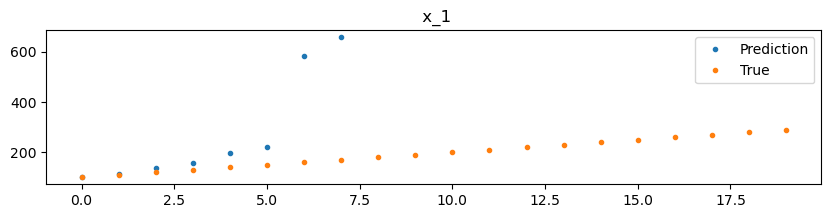

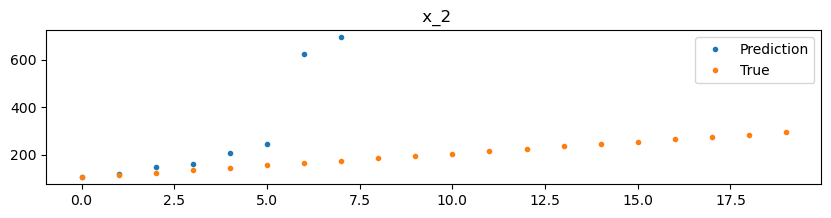

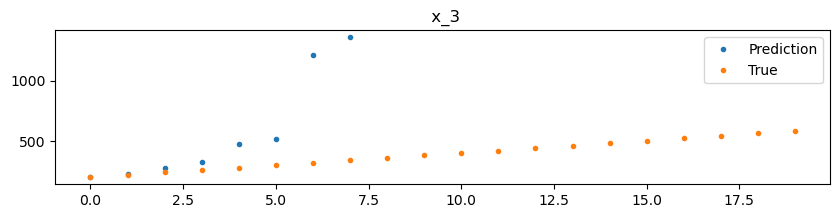

In [170]:
import matplotlib.pyplot as plt

n_features = 3

for i in range(n_features):
    plt.figure(figsize=(10, 2))
    plt.plot(predictions_direct[:, i], linestyle=' ', marker='.', label='Prediction')
    plt.plot(test_dataset[:, i], linestyle=' ', marker='.', label='True')
    plt.title(f' x_{i+1}')
    plt.legend()
    plt.show()